# Mamba-MPC on the Four Tank system

Companion code for *Mamba Sequence Modeling Meets Model Predictive Control*
(Cevaal, de Jong, Lazar), IEEE Open Journal of Control Systems, 2026.

The quadruple-tank process is the paper's MIMO study: four coupled tank levels
driven by two pumps, with the cross-coupling that makes it a standard hard
benchmark. Sections:

1. **Training data** &mdash; piecewise-constant pump settings plus a multisine.
2. **Training** &mdash; fit the Mamba multi-step predictor.
3. **Validation** &mdash; open-loop accuracy on held-out data.
4. **Reference tracking** &mdash; closed-loop MIMO control.
5. **Comparison** &mdash; Mamba-MPC against LSTM-MPC.

All the machinery lives in the `mambampc` package. To reproduce the figures
without retraining, skip to section 3 and run on from the shipped checkpoints.

## Setup

In [1]:
import os
import sys
import pathlib

sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset

from mambampc.data import (
    BestModelSaver,
    HankelMatricesStates,
    Sequence2SequenceStates,
)
from mambampc.models import MambaMPC
from mambampc.plotting import fig_four_tank
from mambampc.mpc import setup_mpc
from mambampc.simulate import run_closed_loop
from mambampc.systems import four_tank, multisine

torch.set_default_dtype(torch.float64)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Plant parameters: outlet areas, valve splits, gravity, tank cross-section.
PARAMS = {
    "a1": 1.31e-4, "a2": 1.51e-4, "a3": 9.27e-5, "a4": 8.82e-5,
    "gamma_a": 0.3, "gamma_b": 0.4, "g": 9.81, "Sc": 0.06,
}
Ts = 5      # sampling time [s]
N = 20      # prediction horizon
print(f"torch {torch.__version__} on {device}")

torch 2.8.0+cpu on cpu


## 1. Training data

Each pump follows a piecewise-constant schedule with a multisine superimposed, so
the record covers both the operating points and the dynamics between them.

In [ ]:
# Piecewise-constant pump levels: u1 switches four times as often as u2, so the
# pair sweeps the operating grid rather than moving together.
u1_levels = np.concatenate([np.tile([v], (500, 1)) for v in (1.0, 1.5, 2.0, 2.5)])
u1_data_all = np.tile(u1_levels, (4, 1))
u2_data_all = np.concatenate([np.tile([v], (2000, 1)) for v in (1.0, 1.5, 2.0, 2.5)])

u1_data = u1_data_all + 0.5 * multisine(
    N_points_per_period=8000, N_periods=1, pmin=1, pmax=500,
    n_crest_factor_optim=100, seed=42).reshape(-1, 1)
u2_data = u2_data_all + 0.5 * multisine(
    N_points_per_period=8000, N_periods=1, pmin=1, pmax=500,
    n_crest_factor_optim=100, seed=36).reshape(-1, 1)
u_data = np.hstack((u1_data, u2_data))

fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].plot(u1_data, lw=0.5); ax[0].set_ylabel("$u_1$"); ax[0].grid(alpha=0.3)
ax[1].plot(u2_data, lw=0.5); ax[1].set_ylabel("$u_2$"); ax[1].set_xlabel("sample")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Integrate one sampling period at a time, carrying the state forward.
x0 = np.array([0.5, 0.5, 0.5, 0.5])
x = [x0]
for i in range(len(u1_data)):
    sol = solve_ivp(
        lambda t, y: four_tank(t, y, float(u1_data[i]), float(u2_data[i]), PARAMS),
        [0, Ts], x0, method="RK45",
    )
    x0 = sol.y[:, -1]
    x.append(x0)
x = np.array(x)
t_vec = np.arange(len(x)) * Ts

np.save("data/FourTank_MS_8000_u.npy", u_data)
np.save("data/FourTank_MS_8000_x.npy", x)

fig, ax = plt.subplots(4, 1, figsize=(9, 6), sharex=True)
for i in range(4):
    ax[i].plot(t_vec, x[:, i], lw=0.6)
    ax[i].set_ylabel(f"$x_{i + 1}$"); ax[i].grid(alpha=0.3)
ax[-1].set_xlabel("t [s]")
plt.tight_layout(); plt.show()

In [ ]:
BatchSize = 128
TestSetSize = 500   # split off the end of the record for validation during training

# The full generated record was saved above. The split below is in-memory only:
# data/Four_Tank_{u,x}_test.npy is a separate held-out set used in section 3 and
# is deliberately not overwritten here.
u_train, x_train = u_data[:len(u_data) - TestSetSize], x[:len(x) - TestSetSize]
u_val, x_val = u_data[len(u_data) - TestSetSize:], x[len(x) - TestSetSize:]

U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(
    torch.DoubleTensor(u_train), torch.DoubleTensor(x_train), N)
X, Y = Sequence2SequenceStates(X0, U_0_Nm1, Y_1_N)

U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(
    torch.DoubleTensor(u_val), torch.DoubleTensor(x_val), N)
X_test, Y_test = Sequence2SequenceStates(X0, U_0_Nm1, Y_1_N)

if device == "cuda":
    X, Y, X_test, Y_test = X.cuda(), Y.cuda(), X_test.cuda(), Y_test.cuda()

train = DataLoader(TensorDataset(X, Y), batch_size=BatchSize, shuffle=False)
test = DataLoader(TensorDataset(X_test, Y_test), batch_size=BatchSize, shuffle=False)
print(f"train {tuple(X.shape)} -> {tuple(Y.shape)} | test {tuple(X_test.shape)}")

## 2. Training

Skip this section to use the shipped checkpoints.

In [ ]:
filename = "ZOH_D8_dstate8_Conv20_dt4_State"
lr, wd, epochs, gamma = 1e-3, 1e-5, 2000, 0.998

X_sample, Y_sample = next(iter(train))
_, _, input_dim = X_sample.shape
_, _, output_dim = Y_sample.shape

model = MambaMPC(input_dim, output_dim, d_model=8, n_layers=1, d_conv=20, d_state=8)
if device == "cuda":
    model = model.cuda()

opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=gamma)
best_model_saver = BestModelSaver(filepath="checkpoints/" + filename)

for e in range(epochs):
    model.train()
    running = 0.0
    for X_b, Y_b in train:
        opt.zero_grad()
        loss = torch.mean((model(X_b).squeeze(0) - Y_b) ** 2) / torch.mean(Y_b ** 2)
        loss.backward()
        opt.step()
        running += loss.item()

    model.eval()
    vloss = 0.0
    with torch.no_grad():
        for X_b, Y_b in test:
            X_b, Y_b = X_b.to(device), Y_b.to(device)
            vloss += (torch.mean((model(X_b) - Y_b) ** 2) / torch.mean(Y_b ** 2)).item()
    average_vloss = vloss / len(test)
    scheduler.step()

    if e % 10 == 0 and e != 0:
        print("Epoch %d | train %.5f | val %.5f" % (e, running / len(train), average_vloss))
        best_model_saver(current_valid_loss=average_vloss, model=model,
                         epoch=e, optimizer=opt, criterion=F.mse_loss)

## 3. Validation

{'in_dim': 6, 'out_dim': 4, 'd_model': 8, 'n_layers': 1, 'd_conv': 20, 'd_state': 8, 'expand_factor': 1, 'dt_rank': 2}
parameters: 708
Hankel Matrices Generated
x1  MAE 0.00462   R^2 0.99639
x2  MAE 0.00712   R^2 0.99750
x3  MAE 0.00792   R^2 0.98438
x4  MAE 0.00912   R^2 0.99756


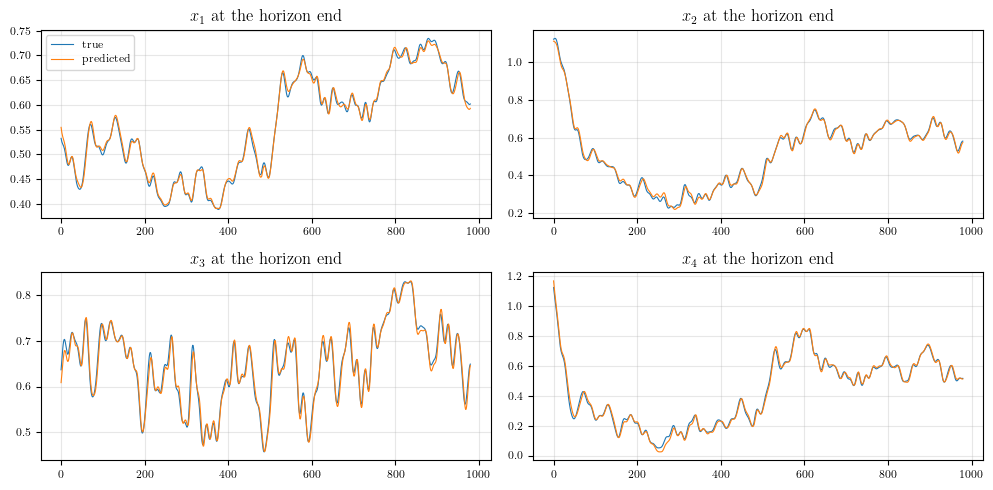

In [3]:
CHECKPOINT = "ZOH_D8_dstate8_Conv20_dt4_State"

sd = torch.load("checkpoints/" + CHECKPOINT, map_location="cpu",
                weights_only=True)["model_state_dict"]
model = MambaMPC(**MambaMPC.config_from_state_dict(sd))
model.load_state_dict(sd)
model = model.double().eval()
print(MambaMPC.config_from_state_dict(sd))
print("parameters:", sum(p.numel() for p in model.parameters()))

u_test = torch.DoubleTensor(np.load("data/Four_Tank_u_test.npy"))
x_test = torch.DoubleTensor(np.load("data/Four_Tank_x_test.npy"))
U_0_Nm1, Y_1_N, X0 = HankelMatricesStates(u_test, x_test, N)
X_test, Y_test = Sequence2SequenceStates(X0, U_0_Nm1, Y_1_N)
test = DataLoader(TensorDataset(X_test, Y_test), batch_size=128, shuffle=False)

with torch.no_grad():
    yhat = torch.cat([model(X_b) for X_b, _ in test]).numpy()
Y_np = Y_test.numpy()

for i in range(4):
    print("x%d  MAE %.5f   R^2 %.5f" % (
        i + 1,
        np.mean(np.abs(yhat[:, :, i] - Y_np[:, :, i])),
        r2_score(Y_np[:, :, i].ravel(), yhat[:, :, i].ravel()),
    ))

fig, ax = plt.subplots(2, 2, figsize=(10, 5))
for i, a in enumerate(ax.ravel()):
    a.plot(Y_np[:, -1, i], lw=0.8, label="true")
    a.plot(yhat[:, -1, i], lw=0.8, label="predicted")
    a.set_title(f"$x_{i + 1}$ at the horizon end"); a.grid(alpha=0.3)
ax[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Closed-loop reference tracking

MIMO tracking across four operating points. Pump inputs are bounded to
$u \in [0, 4]$ and levels are constrained non-negative, matching the physical
limits of the plant.

In [4]:
nx, nu = 4, 2
Q = np.diag([100.0, 100.0, 100.0, 100.0])
R = 0 * np.eye(2)
Rd = np.diag([1.0, 1.0])
S = 0

# Four operating points, each held for 500 steps.
xref_traj = np.concatenate([
    np.tile([0.650, 0.650, 0.652, 0.664], (500, 1)),
    np.tile([0.300, 0.300, 0.301, 0.306], (500, 1)),
    np.tile([0.500, 0.750, 0.305, 1.200], (500, 1)),
    np.tile([0.900, 0.750, 1.062, 0.579], (500, 1)),
])
ksim = xref_traj.shape[0]


def four_tank_plant(state, u):
    """Integrate the plant across one sampling period under a held input."""
    sol = solve_ivp(
        lambda t, y: four_tank(t, y, float(u[0]), float(u[1]), PARAMS),
        [0, Ts], state, method="RK45",
    )
    return sol.y[:, -1]


solver, opt_x_num, opt_p_num, lbx, ubx = setup_mpc(
    model, N=N, n_u=nu, n_x=nx, Q=Q, R=R, Rd=Rd, S=S,
    n_state_params=4, terminal=None,
    u_bounds=(0.0, 4.0), x_bounds=(0.0, np.inf),
)

out = run_closed_loop(
    solver, opt_x_num, opt_p_num, four_tank_plant,
    x0=[0.5, 0.5, 0.5, 0.5], ref=xref_traj, N=N, steps=ksim - N,
    n_u=nu, n_x=nx, lbx=lbx, ubx=ubx, progress=True,
)

np.save("results/mamba/FourTank_MambaMPC_x.npy", out["states"])
np.save("results/mamba/FourTank_MambaMPC_u1.npy", out["inputs"][:, 0])
np.save("results/mamba/FourTank_MambaMPC_u2.npy", out["inputs"][:, 1])
print("median solve time: %.1f ms" % (1e3 * np.median(out["solve_time"])))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

closed loop: 100.0%
median solve time: 44.1 ms


## 5. Comparison with LSTM-MPC

The LSTM trajectories in `results/lstm/` are the stored output of that
controller's own closed-loop run.

Mamba-MPC    MAE 0.01548   MSE 0.00229
LSTM-MPC     MAE 0.02385   MSE 0.00254


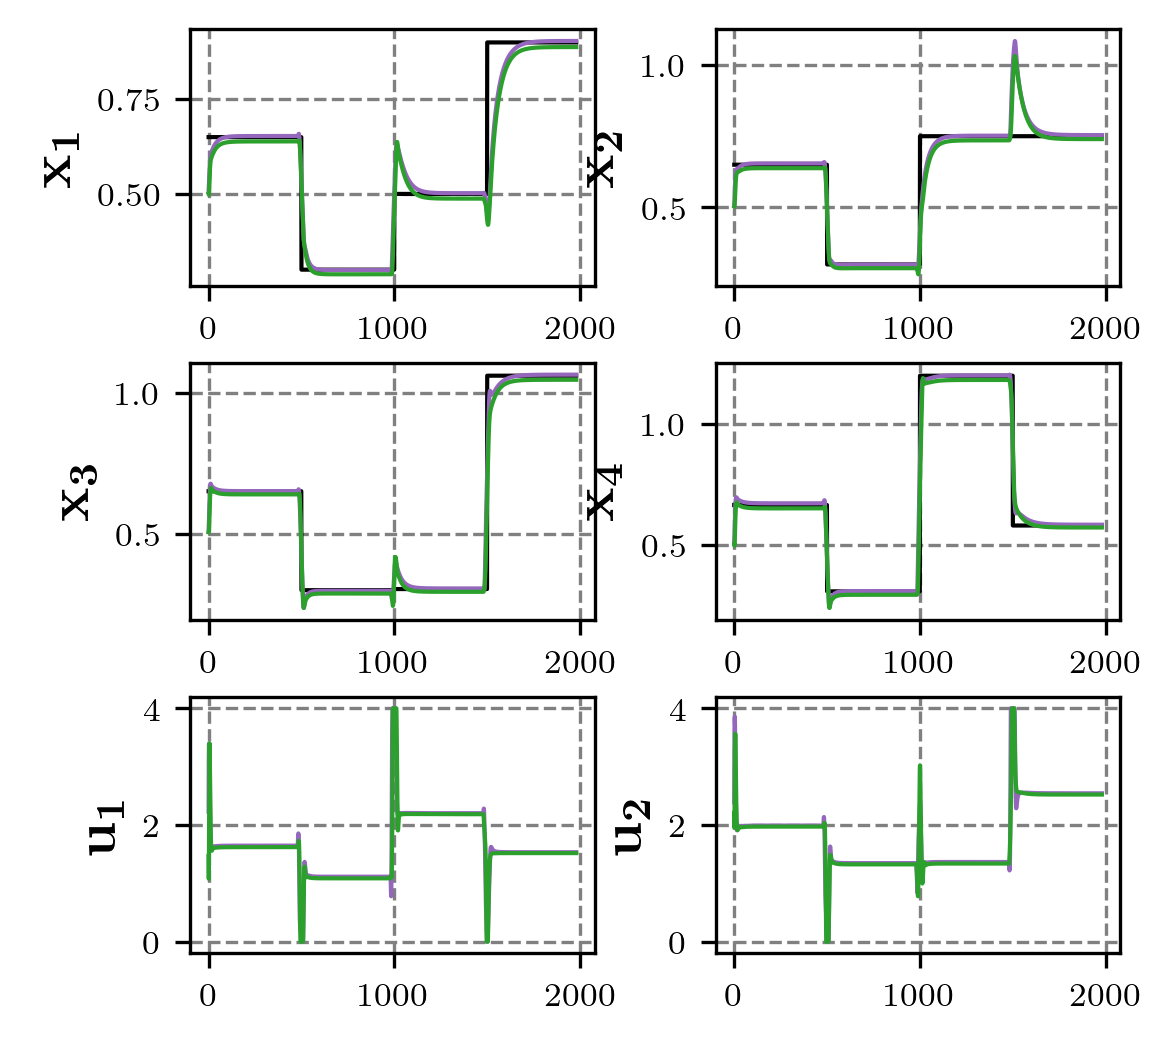

In [5]:
steps = ksim - N
xMamba = out["states"][1:steps + 1]
uMamba = out["inputs"][1:steps + 1]
ref = xref_traj[:steps]

traces = {"Mamba-MPC": (xMamba, uMamba)}
lstm_x = "results/lstm/LSTM_x_vals.npy"
if os.path.exists(lstm_x):
    xLSTM = np.load(lstm_x)[:steps]
    uLSTM = np.column_stack([
        np.load("results/lstm/LSTM_u1_vals.npy")[:steps],
        np.load("results/lstm/LSTM_u2_vals.npy")[:steps],
    ])
    traces["LSTM-MPC"] = (xLSTM, uLSTM)

for label, (xs, _) in traces.items():
    n = min(len(xs), len(ref))
    print("%-12s MAE %.5f   MSE %.5f" % (
        label,
        mean_absolute_error(ref[:n], xs[:n]),
        mean_squared_error(ref[:n], xs[:n]),
    ))

# Paper Fig. 12. Insertion order is draw order: LSTM goes on top.
fig_four_tank(ref, traces, save_to="figures/FourTank_MambaMPC_vs_LSTM-MPC")
plt.show()